In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [15]:
df = pd.read_csv("csd.csv")
df.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [16]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

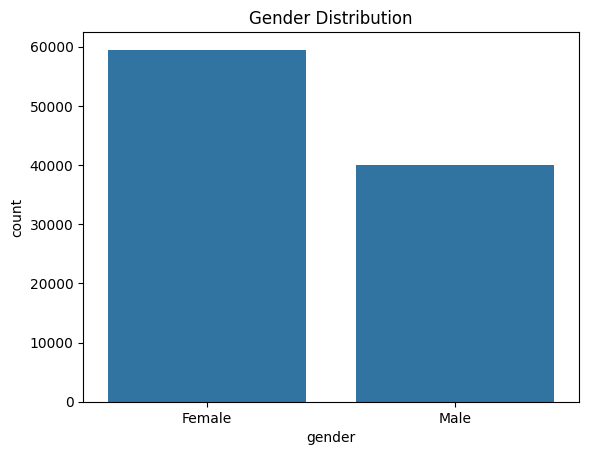

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("csd.csv")

# remove extra spaces
df.columns = df.columns.str.strip()

# correct column name = gender (small g)
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()


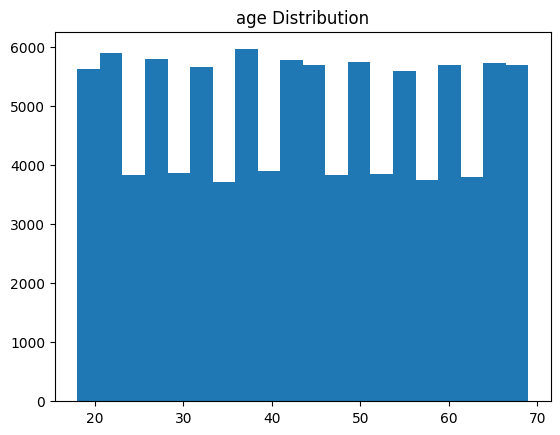

In [19]:
plt.hist(df['age'], bins=20)
plt.title("age Distribution")
plt.show()


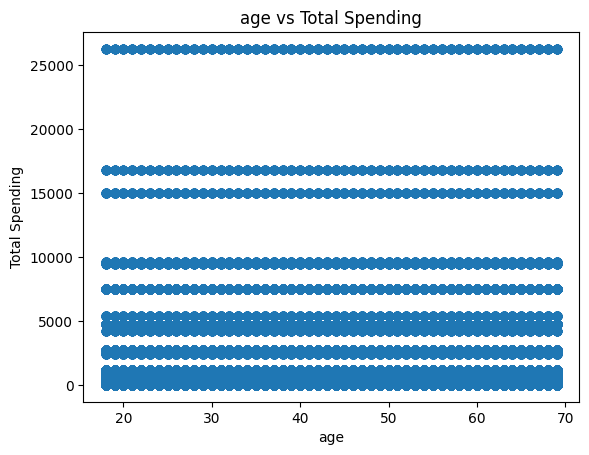

In [23]:
plt.scatter(df['age'], df['total_spending'])
plt.xlabel("age")
plt.ylabel("Total Spending")
plt.title("age vs Total Spending")
plt.show()


In [21]:
df['total_spending'] = df['quantity'] * df['price']


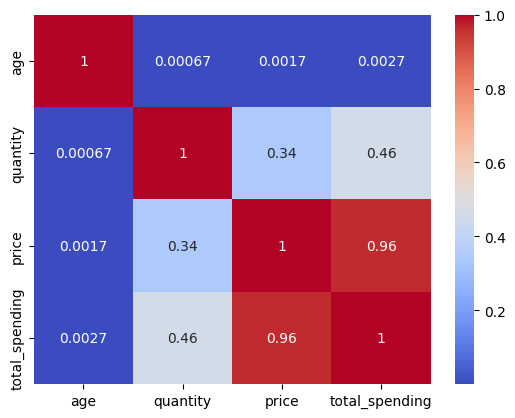

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


In [25]:
df['total_spending'] = df['quantity'] * df['price']


In [ ]:
X = df[['age', 'quantity', 'price', 'total_spending']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



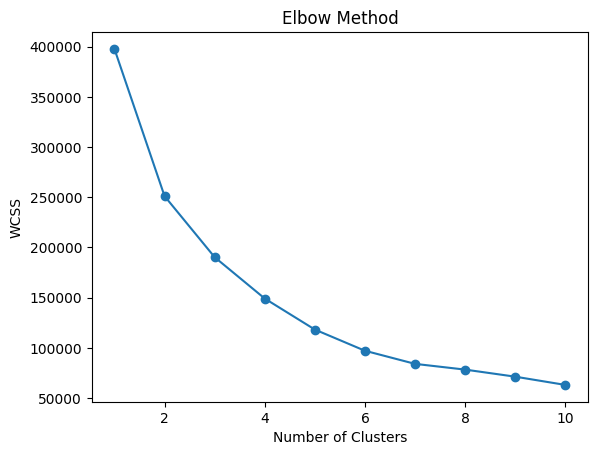

In [32]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [33]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_spending,Cluster
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00,0
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53,0
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08,2
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25,3
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40,4


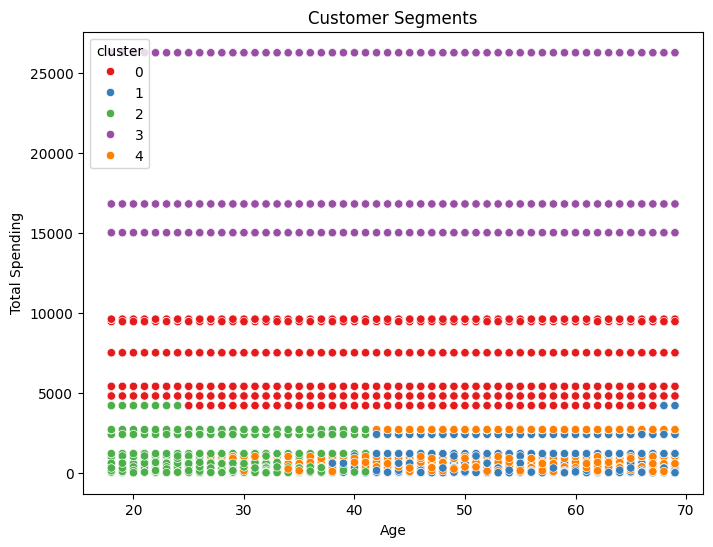

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['age'],
    y=df['total_spending'],
    hue=df['cluster'],   # ab ye exist karta hai
    palette='Set1'
)

plt.title("Customer Segments")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.show()


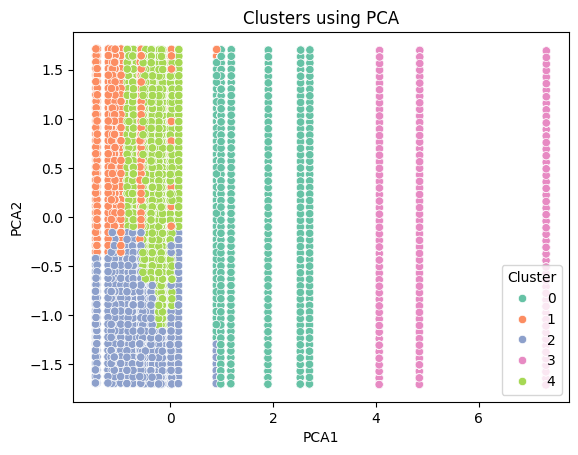

In [38]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2')
plt.title("Clusters using PCA")
plt.show()


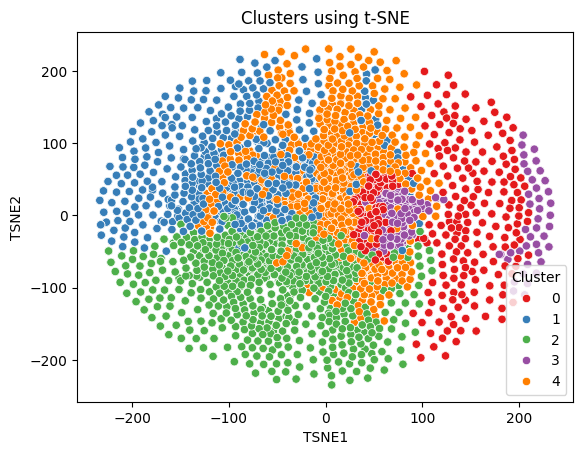

In [39]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df['TSNE1'] = X_tsne[:,0]
df['TSNE2'] = X_tsne[:,1]

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df, palette='Set1')
plt.title("Clusters using t-SNE")
plt.show()


In [41]:
df.groupby('cluster')[['age', 'quantity', 'price', 'total_spending']].mean()


,age,quantity,price,total_spending
cluster,,,,
0,43.571951,4.112856,1629.589316,6520.664221
1,54.392705,1.456359,297.393266,472.462152
2,28.069414,2.395450,307.481990,705.241863
3,43.434122,4.750685,3860.563151,18255.692466
4,51.704615,3.963190,221.524175,772.441512


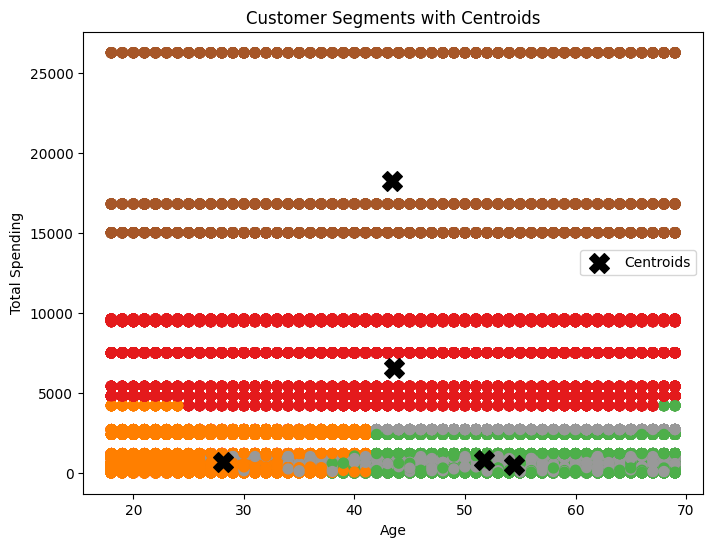

In [43]:
import matplotlib.pyplot as plt

# centroids in original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

# scatter: Age vs Total Spending
plt.scatter(df['age'], df['total_spending'], c=df['cluster'], cmap='Set1', s=50)

# centroids
plt.scatter(
    centroids[:,0],   # age
    centroids[:,3],   # total_spending
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.title("Customer Segments with Centroids")
plt.legend()
plt.show()
